In [1]:
#!pip install camb

In [2]:
# Main dependencies
import scipy.fftpack
from scipy.interpolate import CubicSpline
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import os
import camb
from camb import model, initialpower
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from datetime import date
from datetime import datetime
import math
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

print('Using CAMB %s installed at %s' % (camb.__version__, os.path.dirname(camb.__file__)))
# make sure the version and path is what you expect

print(torch.cuda.device_count())
# prints number of GPUs available

Using CAMB 1.6.5 installed at /global/homes/a/ajtorres/.local/perlmutter/pytorch2.6.0/lib/python3.12/site-packages/camb
4


In [3]:
h = 0.7    # reduced Hubble constant
field_size = 32
fields_num = 40000
batch = 400
epoch_num = 1000
model_num = 2

In [4]:
def fftind(size):
    """ Returns a numpy array of shifted Fourier coordinates k_x k_y k_z.
        
        Input args:
            size (integer): The size of the coordinate array to create
        Returns:
            k_ind, numpy array of shape (3, size, size, size) with:
                k_ind[0,:,:,:]:  k_x components
                k_ind[1,:,:,:]:  k_y components
                k_ind[2,:,:,:]:  k_z components
            
        """
    #Below, I have added an extra ':size' to the make the output 3D
    k_ind = np.mgrid[:size, :size, :size] - int( (size + 1)/2 )
    k_ind = scipy.fftpack.fftshift(k_ind) / (1000*h) * 2*np.pi
    return( k_ind )

In [5]:
# Set cosmological parameters
pars = camb.set_params(H0=67.5, ombh2=0.022, omch2=0.122, ns=0.965)

# Get matter power spectra at redshift 0
pars.set_matter_power(redshifts=[0.0], kmax=2.0)

# Non-Linear spectra (Halofit)
results = camb.get_results(pars)
pars.NonLinear = model.NonLinear_both
results.calc_power_spectra(pars)

# In order to get a reasonable number of galaxies (~10^6), I need my minimum k to be 2*pi*0.001
# Maximum k should then be the number of boxels along one side of the field times the minimum
# k. My fields won't be able to resolve the effects of larger k.

mink = 2*np.pi*0.001 / (2*h) # Divided by 2 to account for maximum squashing
kh_nonlin, z_nonlin, pk_nonlin = results.get_matter_power_spectrum(minkh= mink, maxkh= field_size * mink * 4, npoints= 10000)
# Multiplied by 4 to account for previous division by 2 and the maximum stretching

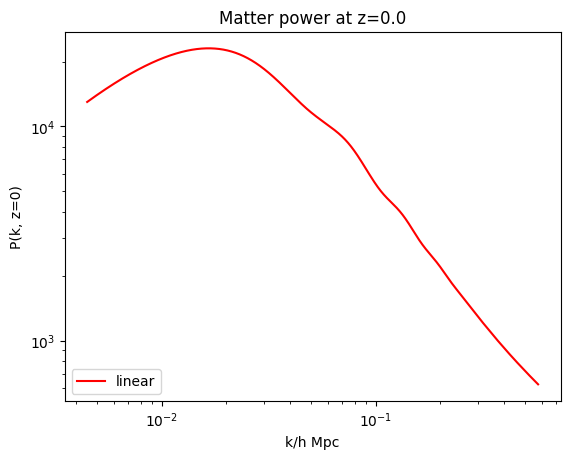

In [6]:
# Quick detour to plot power spectrum
plt.loglog(kh_nonlin, pk_nonlin[0, :], color='r')
plt.ylabel("P(k, z=0)")
plt.xlabel('k/h Mpc')
plt.legend(['linear', 'non-linear'], loc='lower left')
plt.title('Matter power at z=%s' % 0.0);

When I multiply the k's along some axis by a stretch factor, let's say 2, I am considering up to 2 times larger k's and twice as large of a minimum k. This means that the total length of space considered along that axis is a factor of 2 smaller, but I have twice the resolution. Similarly, by dividing the total length of space considered along an axis by a stretch factor, let's say 2 again, I am considering k's that are not quite as large but a smaller minimum k. This translates to a greater length of space considered along that axis just at smaller resolution.

In [7]:
def stretched_power(max_stretch, field_size):
    stretch = np.random.uniform(1 / max_stretch, max_stretch)
    
    # For each position in k-space, I want to calculate the separation from the origin
    k_idx = fftind(field_size)
    
    # We stretch physical space along one or more of the axes by a factor of the stretch
    # Stretch factor multiplied by k_idx[0] stretches the images horizontally
    # Stretch factor multiplied by k_idx[2] stretches the images vertically
    k_sep = np.sqrt((k_idx[0] * stretch)**2 + (k_idx[1])**2 + (k_idx[2])**2)
    
    # Because we have not defined the power spectrum for every k we want to evaluate, we interpolate
    power_interpolator = CubicSpline(kh_nonlin, pk_nonlin[0], extrapolate = False)
    amplitude = power_interpolator(k_sep)
    amplitude[0][0][0] = 0
    
    return amplitude, stretch

In [8]:
def gaussian_random_field(size = field_size, flag_normalize = True):
    """
        Input args:
            size (integer):
                The size of the square output Gaussian Random Fields
            flag_normalize (boolean, default = True):
                Normalizes the Gaussian Field:
                    - to have an average of 0.0
                    - to have a standard deviation of 1.0

        Returns:
            gfield (numpy array of shape (size, size, size)):
                The random gaussian random field
                
        Example:
        import matplotlib.pyplot as plt
        example = gaussian_random_field()
        plt.imshow(example)
        """
 
        # Draws a complex gaussian random noise with normal (circular) distribution
    noise = np.random.normal(size = (size, size, size)) \
        + 1j * np.random.normal(size = (size, size, size))

    power, stretch = stretched_power(max_stretch = 1.1, field_size = size)
    amplitude = np.sqrt(power)
    
        # To real space
    gfield = np.fft.ifftn(noise * amplitude).real
    
        # Sets the standard deviation to one
    if flag_normalize:
        gfield = gfield - np.mean(gfield)
        gfield = gfield/np.std(gfield)
        
    return gfield, stretch

In [9]:
'''
def Gaussian_to_Galaxy_Field(N_gal):
    Gaussian_field, stretch = gaussian_random_field() #This gets us a 3D array with values representing a Gaussian random field with variance 1
    density_field_weights = np.exp(Gaussian_field - 1/2) #Takes Gaussian field and converts it to a realistic density field weighting
    sum_weights = np.sum(density_field_weights)
    galaxy_probs = density_field_weights / sum_weights
    
    # This uses the density field weighting and populates an array representing the actual distribution of galaxies in 3D space
    galaxy_probs_flat = galaxy_probs.flatten()
    N_gal_dist_flat = np.random.multinomial(N_gal, galaxy_probs_flat)
    N_gal_dist = N_gal_dist_flat.reshape((field_size, field_size, field_size))
    return N_gal_dist, Gaussian_field, stretch
''';

In [10]:
'''
# This is to figure out how many galaxies I would have in a box for each tracer
k_min = 1/1000 # Mpc^-1
box_volume = k_min ** -3 # Mpc^3
vol_tracer = 10**9 #Mpc^3
N_gal_tracer = 10**6

N_gal = round(N_gal_tracer / vol_tracer * box_volume) # multiply measured galaxy density by volume of my box
print(N_gal)
''';

In [11]:

#Here we make the training data with each individual image stretched by a different random amount, but that stretch factor can be relatively large
# Numpy array to store labels
labels = torch.zeros(fields_num)

# Numpy array to store field data
Gauss_fields = torch.zeros([fields_num, 1, field_size, field_size, field_size])

for num in range(fields_num):
    #return 3D array with values representing a galaxy field
    Gauss_field, stretch = gaussian_random_field()
        
    # Convert into a tensor
    #Gal_field_tensor = torch.tensor(Gal_field, dtype=torch.float)
    Gauss_field_tensor = torch.tensor(Gauss_field, dtype=torch.float)
    #Gal_fields[num][0] = Gal_field_tensor
    Gauss_fields[num][0] = Gauss_field_tensor
    labels[num] = stretch

In [12]:
from sklearn.model_selection import train_test_split
test_frac = 0.2
train_num = fields_num * (1 - test_frac)
test_num = fields_num * test_frac
# Right now, I am just using the Gaussian fields for training
fields_train, fields_test, labels_train, labels_test = train_test_split(Gauss_fields, labels, test_size = test_frac, random_state = 42)

#This class is meant to take arrays of pixel values and labels and prepare them in a state that the dataloader 
#can process and then give to the neural network
class CustomThrimageDataset():
    def __init__(self, labels, data, transforms = False):
        self.labels = labels
        self.data = data
        self.transforms = transforms

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        thrimage = self.data[idx]
        label = self.labels[idx]
        clonethrimage = thrimage.clone()
        if self.transforms:
            clonethrimage = self.transforms(clonethrimage)
        return clonethrimage, label

In [13]:
#Here we actually define the training and testing datasets in a way that the dataloader can process
training_thrimages = CustomThrimageDataset(labels_train, fields_train)
testing_thrimages = CustomThrimageDataset(labels_test, fields_test)

#Here we tell the dataloader what datasets we are giving it, how many images we want for each batch of training and whether we want the datasets
#to be shuffled between "rounds" of training
train_dataloader = DataLoader(training_thrimages, batch_size=batch, shuffle=True)
test_dataloader = DataLoader(testing_thrimages, batch_size=batch, shuffle=True)

In [14]:
'''
# Test architecture based off VGG-16 NN
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    
    def __init__(self):
        super().__init__()
        # 1 input channel, 64 output channels, and kernel of size 5x5x5 (cube since kernel size given by 1 num) 
        # with padding of 2 to prevent loss of edge information. This starts off 1st convolutional block
        self.conv11 = nn.Conv3d(1, 64, 5, padding = 2)
        self.conv12 = nn.Conv3d(64, 64, 5, padding = 2)

        # 2nd convolutional block. We increase the number of channels with each block to allow for each block to 
        # detect more features (each channel corresponds to a new filter applied to the previous input channels,
        # and each filter is supposed to be able to identify a new feature)
        self.conv21 = nn.Conv3d(64, 128, 5, padding = 2)
        self.conv22 = nn.Conv3d(128, 128, 5, padding = 2)

        # 3rd and final convolutional block. Note that all of these blocks are followed by max pooling
        self.conv31 = nn.Conv3d(128, 256, 5, padding = 2)
        self.conv32 = nn.Conv3d(256, 256, 5, padding = 2)
        self.conv33 = nn.Conv3d(256, 256, 5, padding = 2)

        # "MaxPool3d" defines a 3d kernel of size 2x2x2 that will generate another array from our input array with values 
        # dictated by the max value of the input array within the region of the array covered by the kernel. This makes the  
        self.pool = nn.MaxPool3d(2, 2)

        # The output of the final convolutional layer has 256 channels, and each channel contains a 3D array with size that
        # has been halved three times from the original input field by three maxpools. The padding of size 2 makes sure that 
        # we don't decrease the dimensionality of the data matrix within a given convolutional block
        self.fc1 = nn.Linear(int(256*(field_size/(2**3))**3), 2048)
        self.fc2 = nn.Linear(2048, 512)
        self.fc3 = nn.Linear(512, 1)

    # Forward describes how the network passes information from the input forward through the network
    def forward(self, x):
        # Each layer has a ReLU actication function applied to it
        x = F.relu(self.conv11(x))
        x = self.pool(F.relu(self.conv12(x)))
        
        x = F.relu(self.conv21(x))
        x = self.pool(F.relu(self.conv22(x)))
        
        x = F.relu(self.conv31(x))
        x = F.relu(self.conv32(x))
        x = self.pool(F.relu(self.conv33(x)))

        # torch.flatten takes the output of our final convolutional layer and collapses it down to one channel 1D for the dense
        # layers.The '1' parameter in the torch.flatten function basically tells to leave the network to leave the outermost
        # distinction in our data intact. Here, that is the difference between different thrimages in our batch, so each thrimage 
        # is flattened but not mixed together.
        x = torch.flatten(x, 1)

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

net = Net()
''';

In [20]:
if model_num == 1:
    # Original, very simple network architecture
    class Net(nn.Module):
        
        def __init__(self):
            super().__init__()
            #1 input channel, 6 output channels, and kernel of size 5x5x5 (cube since kernel size given by 1 num)
            self.conv1 = nn.Conv3d(1, 6, 5, padding = 2)
    
            #"MaxPool3d" defines a 3d kernel of size 2x2x2 that will generate another array from our input array with 
            #values dictated by the max value of the input array within the region of the array covered by the kernel. This makes the 
            #neural net convolutional, and the result is a new array of 1 less unit height, width, and depth than our input array 
            self.pool = nn.MaxPool3d(2, 2)
            self.conv2 = nn.Conv3d(6, 16, 5,  padding = 2)
    
        
            self.fc1 = nn.Linear(int(16 * field_size/(2**2) * field_size/(2**2) * field_size/(2**2)) , 1000)
            self.fc2 = nn.Linear(1000, 200)
            self.fc3 = nn.Linear(200, 1)
    
        #Forward describes how the network passes information from the input forward through the network
        def forward(self, x):
            #specify pass through two convolutional layers each with a ReLU activation function
            x = self.pool(F.relu(self.conv1(x)))
            x = self.pool(F.relu(self.conv2(x)))
    
            x = torch.flatten(x, 1)
            
            x = F.relu(self.fc1(x))
            x = F.relu(self.fc2(x))
            x = self.fc3(x)
            return x

if model_num == 2:
    #This is a slightly deeper convolutional network architecture
    class Net(nn.Module):
        
        def __init__(self):
            super().__init__()
            #1 input channel, 6 output channels, and kernel of size 5x5x5 (cube since kernel size given by 1 num)
            self.conv11 = nn.Conv3d(1, 6, 5, padding = 2)
            self.conv12 = nn.Conv3d(6, 16, 5, padding = 2)
            self.conv13 = nn.Conv3d(16, 16, 5,  padding = 2)
    
            #"MaxPool3d" defines a 3d kernel of size 2x2x2 that will generate another array from our input array with 
            #values dictated by the max value of the input array within the region of the array covered by the kernel. This makes the 
            #neural net convolutional, and the result is a new array of 1 less unit height, width, and depth than our input array 
            self.pool = nn.MaxPool3d(2, 2)
    
            self.fc1 = nn.Linear(int(16 * (field_size/(2**2))**3) , 1000)
            self.fc2 = nn.Linear(1000, 200)
            self.fc3 = nn.Linear(200, 1)
    
        #Forward describes how the network passes information from the input forward through the network
        def forward(self, x):
            #specify pass through two convolutional layers each with a ReLU activation function
            x = F.relu(self.conv11(x))
            x = self.pool(F.relu(self.conv12(x)))
            x = self.pool(F.relu(self.conv13(x)))
    
            # The '1' parameter in the torch.flatten function basically tells to leave the network to leave the outermost distinction in our data 
            # intact. Here, that is the difference between different thrimages in our batch, so each thrimage is flattened but not mixed together.
            x = torch.flatten(x, 1)
    
            x = F.relu(self.fc1(x))
            x = F.relu(self.fc2(x))
            x = self.fc3(x)
            return x

if model_num == 3:
    #This is an even deeper convolutional network architecture
    class Net(nn.Module):
        
        def __init__(self):
            super().__init__()
            #1 input channel, 6 output channels, and kernel of size 5x5x5 (cube since kernel size given by 1 num)
            self.conv11 = nn.Conv3d(1, 6, 5, padding = 2)
            self.conv12 = nn.Conv3d(6, 16, 5, padding = 2)
            
            self.conv21 = nn.Conv3d(16, 32, 5,  padding = 2)
            self.conv22 = nn.Conv3d(32, 32, 5,  padding = 2)
    
            #"MaxPool3d" defines a 3d kernel of size 2x2x2 that will generate another array from our input array with 
            #values dictated by the max value of the input array within the region of the array covered by the kernel. This makes the 
            #neural net convolutional, and the result is a new array of 1 less unit height, width, and depth than our input array 
            self.pool = nn.MaxPool3d(2, 2)
    
            self.fc1 = nn.Linear(int(32 * (field_size/(2**2))**3) , 1000)
            self.fc2 = nn.Linear(1000, 200)
            self.fc3 = nn.Linear(200, 1)
    
        #Forward describes how the network passes information from the input forward through the network
        def forward(self, x):
            #specify pass through two convolutional layers each with a ReLU activation function
            x = F.relu(self.conv11(x))
            x = self.pool(F.relu(self.conv12(x)))
            x = F.relu(self.conv21(x))
            x = self.pool(F.relu(self.conv22(x)))
    
            # The '1' parameter in the torch.flatten function basically tells to leave the network to leave the outermost distinction in our data 
            # intact. Here, that is the difference between different thrimages in our batch, so each thrimage is flattened but not mixed together.
            x = torch.flatten(x, 1)
    
            x = F.relu(self.fc1(x))
            x = F.relu(self.fc2(x))
            x = self.fc3(x)
            return x

if model_num == 4:
    #This is the same depth as the previous architecture with a slightly wider fully connected head
    class Net(nn.Module):
        
        def __init__(self):
            super().__init__()
            #1 input channel, 6 output channels, and kernel of size 5x5x5 (cube since kernel size given by 1 num)
            self.conv11 = nn.Conv3d(1, 6, 5, padding = 2)
            self.conv12 = nn.Conv3d(6, 16, 5, padding = 2)
            
            self.conv21 = nn.Conv3d(16, 32, 5,  padding = 2)
            self.conv22 = nn.Conv3d(32, 32, 5,  padding = 2)
    
            #"MaxPool3d" defines a 3d kernel of size 2x2x2 that will generate another array from our input array with 
            #values dictated by the max value of the input array within the region of the array covered by the kernel. This makes the 
            #neural net convolutional, and the result is a new array of 1 less unit height, width, and depth than our input array 
            self.pool = nn.MaxPool3d(2, 2)
    
            self.fc1 = nn.Linear(int(32 * (field_size/(2**2))**3) , 2000)
            self.fc2 = nn.Linear(2000, 400)
            self.fc3 = nn.Linear(400, 1)
    
        #Forward describes how the network passes information from the input forward through the network
        def forward(self, x):
            #specify pass through two convolutional layers each with a ReLU activation function
            x = F.relu(self.conv11(x))
            x = self.pool(F.relu(self.conv12(x)))
            x = F.relu(self.conv21(x))
            x = self.pool(F.relu(self.conv22(x)))
    
            # The '1' parameter in the torch.flatten function basically tells to leave the network to leave the outermost distinction in our data 
            # intact. Here, that is the difference between different thrimages in our batch, so each thrimage is flattened but not mixed together.
            x = torch.flatten(x, 1)
    
            x = F.relu(self.fc1(x))
            x = F.relu(self.fc2(x))
            x = self.fc3(x)
            return x

net = nn.DataParallel(Net())

device = torch.device("cuda:0")
net.to(device);

In [21]:
criterion = nn.MSELoss()
lr = 0.001
optimizer = optim.SGD(net.parameters(), lr = lr, momentum = 0.9)

In [25]:
today = date.today()

epochs = np.zeros(epoch_num)
train_loss = np.zeros(epoch_num)
val_loss = np.zeros(epoch_num)
best_loss = 1000000

s = datetime.now()
#loop over the dataset multiple times
for epoch in range(epoch_num):
    train_running_loss = 0.0
    test_running_loss = 0.0
    test_running_loss_avg = 0.0
    #enumerate assigns each entry in train_dataloader, a single batch, to the variable data. i is a number enumerating each batch in train
    for i, data in enumerate(train_dataloader):
        #inputs is a list of all the thrimages in the batch and labels is a list of all the stretch factors in the batch
        inputs = data[0].to(device)
        labels = data[1].to(device)
        
        #zero the parameter gradients between batches ran through the network so that they don't blow up
        optimizer.zero_grad()
        
        ##This block contains our forward + backward + optimize steps##
        
        #convert the thrimage tensors into the float32 tensor type
        inputs = inputs.float()
        
        #run thrimages through network and get the network's guess for the stretch factor for each image in the batch
        outputs = net(inputs)
        
        #"squeeze" out any single value arrays (get rid of unneeded brackets)
        outputs = outputs.squeeze()
        
        # Ensure output is a float32 value
        outputs = outputs.float()
        
        # Ensure labels are float32
        labels = labels.float()
        
        #Compute loss, just the square of the difference between the actual stretch factor and what the network guesses
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_running_loss += loss.item()
        '''
        This segment of code effectively checks if we have ran through the entire image dataset during training. It does this by checking if the number
        of batches loaded is equal to the number of batches the dataset can be divided into rounded up. It then prints the ith iteration through the
        dataset that we are currently on and the average loss per image for that iteration through the dataset
        '''
        if i + 1 == math.ceil(train_num/batch):
            #averages running_loss over all the batches in one iteration of the dataset
            train_avg_loss = np.sqrt(train_running_loss/(i+1))
            print(f'[{epoch + 1}] loss: {train_avg_loss:.6f}')
            train_loss[epoch] = train_avg_loss
            
    #This is where we save the best test dataset and determine the accuracy of the neural network at 
    for j, data in enumerate(test_dataloader):
        #inputs is a list of all the images in the batch and labels is a list of all the stretch factors in the batch
        inputs = data[0].to(device)
        labels = data[1].to(device)
        inputs = inputs.float()
        outputs = net(inputs)
        outputs = outputs.squeeze()
        outputs = outputs.float()
        labels = labels.float()
        loss = criterion(outputs, labels)
        test_running_loss += loss.item()
        
        if j + 1 == math.ceil(test_num/batch):
            test_avg_loss = test_running_loss/(j+1)
            print("Average deviation of network guess from actual stretch is approximately: " + str("{0:.3f}".format(np.sqrt(test_avg_loss))))
            epochs[epoch] = epoch
            val_loss[epoch] = np.sqrt(test_avg_loss)

            if test_avg_loss < best_loss:
                best_loss = test_avg_loss
                model_path = f'nnet_gauss_{today}.pth'
                # Uncomment to save the network for when we are getting actual learning to happen, and the network is worth saving for later
                torch.save(net.state_dict(), model_path)
                

print('Finished Training')
e = datetime.now()

elapsed = (e - s).total_seconds() 
print("Elapsed:", elapsed, "s")

[1] loss: 0.024168
Average deviation of network guess from actual stretch is approximately: 0.025
[2] loss: 0.024111
Average deviation of network guess from actual stretch is approximately: 0.025
[3] loss: 0.024093
Average deviation of network guess from actual stretch is approximately: 0.025
[4] loss: 0.024340
Average deviation of network guess from actual stretch is approximately: 0.025
[5] loss: 0.024167
Average deviation of network guess from actual stretch is approximately: 0.025
[6] loss: 0.024161
Average deviation of network guess from actual stretch is approximately: 0.025
[7] loss: 0.024109
Average deviation of network guess from actual stretch is approximately: 0.025
[8] loss: 0.024167
Average deviation of network guess from actual stretch is approximately: 0.025
[9] loss: 0.024082
Average deviation of network guess from actual stretch is approximately: 0.025
[10] loss: 0.024271
Average deviation of network guess from actual stretch is approximately: 0.025
[11] loss: 0.024044

In [17]:
epochs_save = epochs
train_loss_save = train_loss
val_loss_save = val_loss

In [45]:
train_loss_save_rm = train_loss_save[train_loss_save != 0]
val_loss_save_rm = val_loss_save[val_loss_save != 0]

train_loss_tot = np.append(train_loss_save_rm, train_loss)
val_loss_tot = np.append(val_loss_save_rm, val_loss)

train_loss_tot = train_loss_tot[train_loss_tot != 0]
val_loss_tot = val_loss_tot[val_loss_tot != 0]
epochs_tot = np.array(range(len(train_loss_tot)))

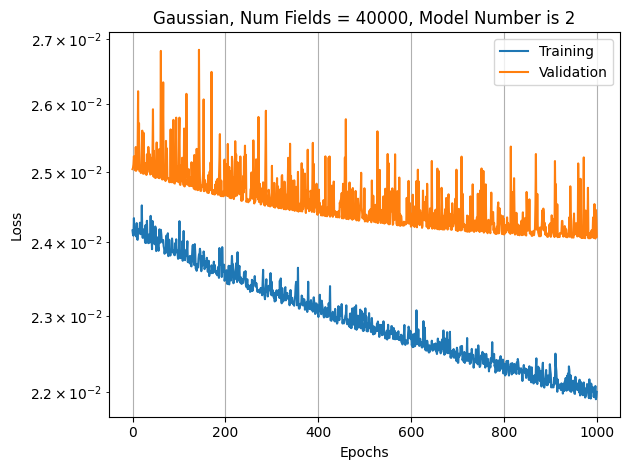

In [27]:
plt.semilogy(epochs, train_loss, label = "Training")
plt.semilogy(epochs, val_loss, label = "Validation")
plt.title(f"Gaussian, Num Fields = {fields_num}, Model Number is {model_num}")
plt.xlabel("Epochs")
plt.ylabel("Loss")
#plt.ylim(0.024, 0.06)
plt.grid()
plt.legend()
plt.tight_layout()
plt.savefig(f"Gauss_{fields_num}_{model_num}_{epoch_num}_smaller_stretch_2nd_realization_2.pdf")

In [42]:
np.savetxt("gauss_small_train_losses.txt", train_loss_tot, delimiter=",")
np.savetxt("gauss_small_valid_losses.txt", val_loss_tot, delimiter=",")

In [26]:
print(np.sqrt(best_loss))

0.02405433373781147
